In [1]:
import json 
import csv 
import pandas as pd 
import numpy as np 

from sklearn.linear_model import LinearRegression

In [ ]:
# Features: 
"""
1. Mean food sentiment 
    - avergae of food_sentiment_score
    - baseline for how good the food is
    - mean_sentiment = 1/N * sum(s_i) 

2. Sentiment Constancy (variance penalty)
    - A place that's always 8-9 is better than a place that flips between 10 and 3 
    - consistency = 1 - std_sentiment / max_possible_std (5)

3. Sentiment trend over time 
    - sentiment = a*time + b 
    - slope = trend 
    - positive slope = food quality improving 
    - negative slope = food quality declining

4. Recency Weight Sentiment 
    - Instead of punishing old restaurant, we do soft recency weighting 
    - not exactly popularity, it's more like "what do people think now" 
    - weight per review w = e^(-lambda * age_years), lambda = 0.15 aka small since 
    we want old reviews to still matter 
    - recency_weighted_mean = sum(w_i * s_i) / sum(w_i)

5. Ratio of High vs Low Sentiment Reviews 
    - high = # reviews with sentiment >= 8
    - low = # reviews with sentiment <= 3 
    - quality ratio = high + 1 / low + 1 
    - ratio_score = log(quality_ratio)

6. Useful-weight sentiment 
    - giving trust to reviews that are marked useful by other users 
    - w = log(1 + useful_votes)
"""

In [ ]:
# load data 
df = pd.read_csv("ca_restaurant_reviews_with_sentiment_combined.csv")

# date column 
df['date'] = pd.to_datetime(df['date'])

# Helpers 
def recency_weighted_mean(group, lambda_decay=0.15):
    max_date = group['date'].max()
    age_years = (max_date - group['date']).dt.days / 365
    weights = np.exp(-lambda_decay * age_years)
    return np.sum(weights * group['food_sentiment_score']) / np.sum(weights)

def useful_weighted_mean(group):
    weights = np.log1p(group['useful']) + 1
    return np.sum(weights * group['food_sentiment_score']) / np.sum(weights)

def sentiment_trend(group):
    if len(group) < 5:
        return 0
    
    X = (group['date'] - group['date'].min()).dt.days.values.reshape(-1,1)
    y = group['food_sentiment_score'].values
    
    model = LinearRegression().fit(X, y)
    return model.coef_[0]

def high_low_ratio(group):
    high = np.sum(group['food_sentiment_score'] >= 8)
    low = np.sum(group['food_sentiment_score'] <= 3)
    return np.log((high + 1) / (low + 1))

# aggregate per restaurant
agg = df.groupby('business_id').apply(lambda g: pd.Series({
    "mean_sentiment": g['food_sentiment_score'].mean(),
    "std_sentiment": g['food_sentiment_score'].std(),
    "recency_weighted": recency_weighted_mean(g),
    "useful_weighted": useful_weighted_mean(g),
    "trend": sentiment_trend(g),
    "ratio_score": high_low_ratio(g),
    "review_count": len(g)
})).reset_index()

# fill NaN 
agg['std_sentiment'] = agg['std_sentiment'].fillna(0)

# convert std -> consistency score 
agg['consistency'] = 1 - (agg['std_sentiment'] / 5)
agg['consistency'] = agg['consistency'].clip(0,1)

# normalize features 0-1 
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

features = [
    'mean_sentiment',
    'recency_weighted',
    'useful_weighted',
    'consistency',
    'ratio_score',
    'trend'
]

for f in features:
    agg[f] = normalize(agg[f])

# final gem score 

agg['gem_score'] = (
    0.25 * agg['mean_sentiment'] +
    0.20 * agg['recency_weighted'] +
    0.15 * agg['consistency'] +
    0.15 * agg['useful_weighted'] +
    0.15 * agg['ratio_score'] +
    0.10 * agg['trend']
)

# sort best restaurants
gem_rankings = agg.sort_values("gem_score", ascending=False)
# final gem score 
gem_rankings.to_csv("gem_restaurant_rankings.csv", index=False)

print(gem_rankings.head(20))

                 business_id  mean_sentiment  std_sentiment  recency_weighted  \
396   M3LZKA-tVFRJyPeKA3_2OA        1.000000       0.527046          1.000000   
792   k3lTRgvPvYUI-cX7_TAqNA        0.935362       1.337457          0.951534   
692   dutm97q2F4a6RV6YQ0uLHw        0.870229       0.564076          0.883887   
454   PilMA5jBSjfh2rlCLG50Cw        0.913949       0.750757          0.918615   
320   H5bsmYmdO3FBVQHC3jfx2g        0.938931       0.707107          0.948605   
178   8Lbz0hfE4MWzd7yDu9atBA        0.868916       1.118709          0.882157   
994   xUd0QOyVzx9SQhWulcOPAw        0.858233       1.186414          0.868735   
751   hfN0fllM3m2jykAgToRTlQ        0.842456       0.777814          0.855046   
636   aQBWiMlM2nEIx3EIjLRGBg        0.821156       0.540062          0.831894   
157   6acxMT_WGbA-cUN5RXpIfw        0.900763       1.074055          0.912661   
437   OMWhamtXhqlYCj66MqcxuQ        0.908397       0.971825          0.920028   
344   IPhNJz_PZQxjTXnC94YdNQ

In [3]:
print(len(gem_rankings))

1035


In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# load data 
df = pd.read_csv("ca_restaurant_reviews_with_sentiment_combined.csv")

# date column 
df['date'] = pd.to_datetime(df['date'])

# Helpers 
def recency_weighted_mean(group, lambda_decay=0.15):
    max_date = group['date'].max()
    age_years = (max_date - group['date']).dt.days / 365
    weights = np.exp(-lambda_decay * age_years)
    return np.sum(weights * group['food_sentiment_score']) / np.sum(weights)

def useful_weighted_mean(group):
    weights = np.log1p(group['useful']) + 1
    return np.sum(weights * group['food_sentiment_score']) / np.sum(weights)

def sentiment_trend(group):
    if len(group) < 5:
        return 0
    
    X = (group['date'] - group['date'].min()).dt.days.values.reshape(-1,1)
    y = group['food_sentiment_score'].values
    
    model = LinearRegression().fit(X, y)
    return model.coef_[0]

def high_low_ratio(group):
    high = np.sum(group['food_sentiment_score'] >= 8)
    low = np.sum(group['food_sentiment_score'] <= 3)
    return np.log((high + 1) / (low + 1))

# aggregate per restaurant
agg = df.groupby('business_id').apply(lambda g: pd.Series({
    "mean_sentiment": g['food_sentiment_score'].mean(),
    "std_sentiment": g['food_sentiment_score'].std(),
    "recency_weighted": recency_weighted_mean(g),
    "useful_weighted": useful_weighted_mean(g),
    "trend": sentiment_trend(g),
    "ratio_score": high_low_ratio(g),
    "review_count": len(g),
    "stars": g['stars'].mean(),
    "vote_count": (g['useful'] + g['funny'] + g['cool']).sum()
})).reset_index()

# fill NaN 
agg['std_sentiment'] = agg['std_sentiment'].fillna(0)

# convert std -> consistency score 
agg['consistency'] = 1 - (agg['std_sentiment'] / 5)
agg['consistency'] = agg['consistency'].clip(0,1)

# normalize features 0-1 
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

gem_features = [
    'mean_sentiment',
    'recency_weighted',
    'useful_weighted',
    'consistency',
    'ratio_score',
    'trend'
]

for f in gem_features:
    agg[f] = normalize(agg[f])

# final gem score 
agg['gem_score'] = (
    0.25 * agg['mean_sentiment'] +
    0.20 * agg['recency_weighted'] +
    0.15 * agg['consistency'] +
    0.15 * agg['useful_weighted'] +
    0.15 * agg['ratio_score'] +
    0.10 * agg['trend']
)


# Normalize popularity features
agg['review_count_norm'] = normalize(np.log1p(agg['review_count']))  # log to reduce skew
agg['stars_norm'] = normalize(agg['stars'])
agg['vote_norm'] = normalize(np.log1p(agg['vote_count']))
agg['consistency_norm'] = normalize(agg['consistency'])

# Weighted popularity score (sum = 1)
agg['popularity_score'] = (
    0.30 * agg['review_count_norm'] +
    0.25 * agg['stars_norm'] +
    0.20 * agg['vote_norm'] +
    0.25 * agg['consistency_norm']
)

# define blown-up threshold (top 10% in review_count)
threshold = agg['review_count_norm'].quantile(0.9)
blown_up = agg[agg['review_count_norm'] >= threshold].copy()
non_blown_up = agg[agg['review_count_norm'] < threshold].copy()

# keep only necessary columns
blown_up_csv = blown_up[['business_id', 'gem_score', 'popularity_score']]
non_blown_up_csv = non_blown_up[['business_id', 'gem_score', 'popularity_score']]

# save CSVs
blown_up_csv.to_csv("blown_up_restaurants.csv", index=False)
non_blown_up_csv.to_csv("non_blown_up_restaurants.csv", index=False)

print("Top 5 blown-up restaurants:")
print(blown_up_csv.sort_values("popularity_score", ascending=False).head())

print("\nTop 5 non-blown-up restaurants:")
print(non_blown_up_csv.sort_values("popularity_score", ascending=False).head())

Top 5 blown-up restaurants:
                business_id  gem_score  popularity_score
315  GuzbBFraIq-fbkjfvaTRvg   0.740928          0.844753
528  U3grYFIeu6RgAAQgdriHww   0.722793          0.823846
202  9ugpNKKhnYRa51qXoxUw_A   0.717126          0.804343
464  QaFbv7aLQBcfT4xMF1_WnQ   0.734494          0.798077
822  m4kvY0viCwxqRtgOycnKVQ   0.747770          0.798014

Top 5 non-blown-up restaurants:
                business_id  gem_score  popularity_score
967  vyOVT4bcW227LRwJGHTeSw   0.800902          0.786551
178  8Lbz0hfE4MWzd7yDu9atBA   0.858113          0.755998
942  uO39--k_hrCFgZh-Bl8m8A   0.739896          0.732083
80   2bl6G1zgXUHbMGwEocqMSg   0.791233          0.724214
622  _ecVi-tVoaKHKYxNkxFj7w   0.693187          0.719535


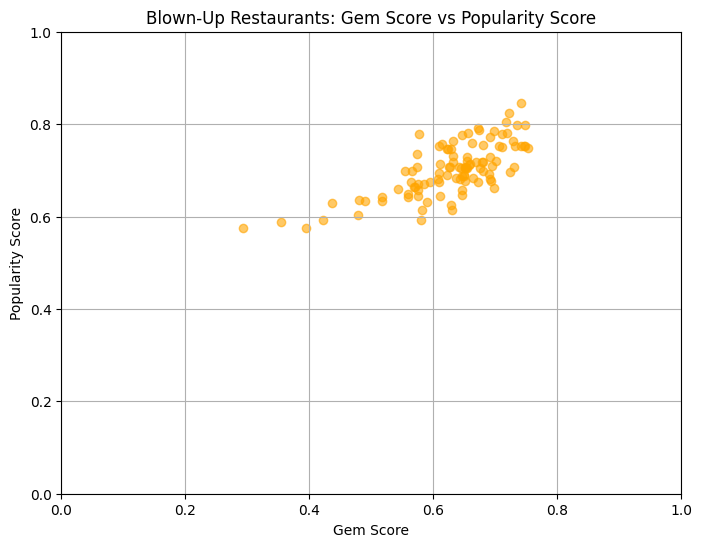

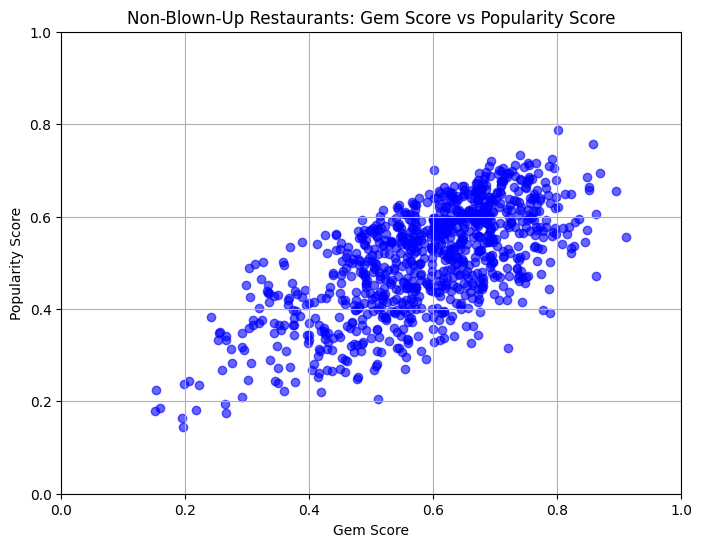

In [5]:
import matplotlib.pyplot as plt

# Blown-up restaurants scatter plot
plt.figure(figsize=(8,6))
plt.scatter(blown_up_csv['gem_score'], blown_up_csv['popularity_score'], alpha=0.6, color='orange')
plt.title("Blown-Up Restaurants: Gem Score vs Popularity Score")
plt.xlabel("Gem Score")
plt.ylabel("Popularity Score")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(True)
plt.show()

# Non-blown-up restaurants scatter plot
plt.figure(figsize=(8,6))
plt.scatter(non_blown_up_csv['gem_score'], non_blown_up_csv['popularity_score'], alpha=0.6, color='blue')
plt.title("Non-Blown-Up Restaurants: Gem Score vs Popularity Score")
plt.xlabel("Gem Score")
plt.ylabel("Popularity Score")
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [18]:
# 75th percentile for gem score
gem_thresh = non_blown_up_csv['gem_score'].quantile(0.75)

# 40th percentile for popularity (lower popularity)
pop_thresh = non_blown_up_csv['popularity_score'].quantile(0.4)

hidden_gems = non_blown_up_csv[
    (non_blown_up_csv['gem_score'] >= gem_thresh) & 
    (non_blown_up_csv['popularity_score'] <= pop_thresh)
]

print(hidden_gems)

# thresholds
gem_thresh = non_blown_up_csv['gem_score'].quantile(0.75)
pop_thresh = non_blown_up_csv['popularity_score'].quantile(0.4)

# create boolean column for all restaurants
non_blown_up_csv['is_hidden_gem'] = (
    (non_blown_up_csv['gem_score'] >= gem_thresh) &
    (non_blown_up_csv['popularity_score'] <= pop_thresh)
)

# Save full dataset with the hidden gem column
non_blown_up_csv.to_csv("ca_restaurants_with_hidden_gem_flag.csv", index=False)

# (Optional) save only the hidden gems
# hidden_gems.to_csv("ca_hidden_gems_only.csv", index=False)

                business_id  gem_score  popularity_score     gem_z     pop_z  \
10   -Lwq2vdrQolANLzEbYMPpQ   0.694774          0.476922  0.807377 -0.261851   
24   -veGIq3SvwFMi5ZwMSIqkg   0.711959          0.448880  0.939745 -0.505852   
39   0iLgVQpBeIYYwQZIblTTVw   0.697763          0.432372  0.830401 -0.649496   
61   2-cH9tqCu3yHRJJoKTYjHw   0.738610          0.473557  1.145017 -0.291126   
96   3cnjGli5iwGsUF06Dne9Yg   0.786284          0.443360  1.512221 -0.553890   
165  7grEnJV48N6BxbEP3uxISA   0.722542          0.471052  1.021257 -0.312926   
181  8QvcM8Nvwite-DOgdYllOw   0.742731          0.414961  1.176760 -0.800999   
192  9L-MR0arflwFMF9szEBOOg   0.708381          0.468202  0.912184 -0.337727   
306  GEGTsaKaO1R9fFB4sGS5qw   0.752420          0.471728  1.251386 -0.307043   
317  Gz2Q1zFXJgnKHOkFdCR9fg   0.743386          0.468329  1.181804 -0.336625   
320  H5bsmYmdO3FBVQHC3jfx2g   0.862101          0.470619  2.096190 -0.316698   
336  HtxYbysdeXwexRrSkKdt2A   0.738991  

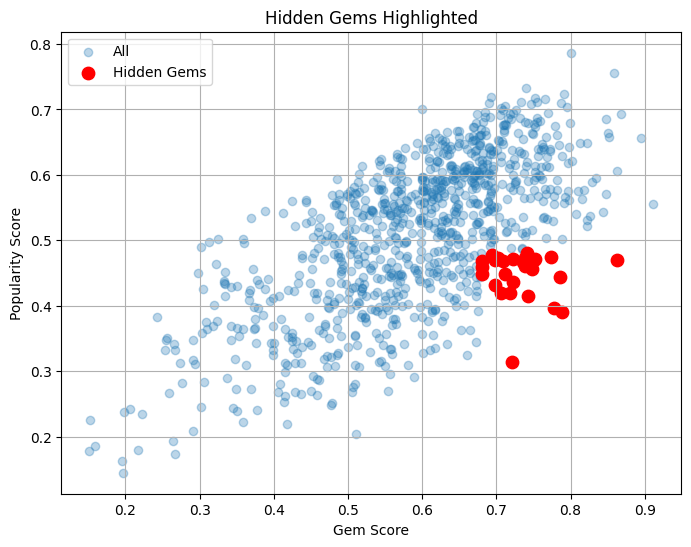

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(non_blown_up_csv['gem_score'], non_blown_up_csv['popularity_score'], alpha=0.3, label="All")
plt.scatter(hidden_gems['gem_score'], hidden_gems['popularity_score'], color='red', label="Hidden Gems", s=80)
plt.xlabel("Gem Score")
plt.ylabel("Popularity Score")
plt.title("Hidden Gems Highlighted")
plt.legend()
plt.grid(True)
plt.show()